In [1]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

In [2]:
import os
import sys
import numpy as np
import torch
from torch import nn
from astropy.table import Table
from tqdm import tqdm
import random
import importlib
import pandas as pd
from astropy.io import fits

from scipy.stats import norm, uniform

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Mock data: with perturbed mass-luminosity relation from isochrones

Generating samples...


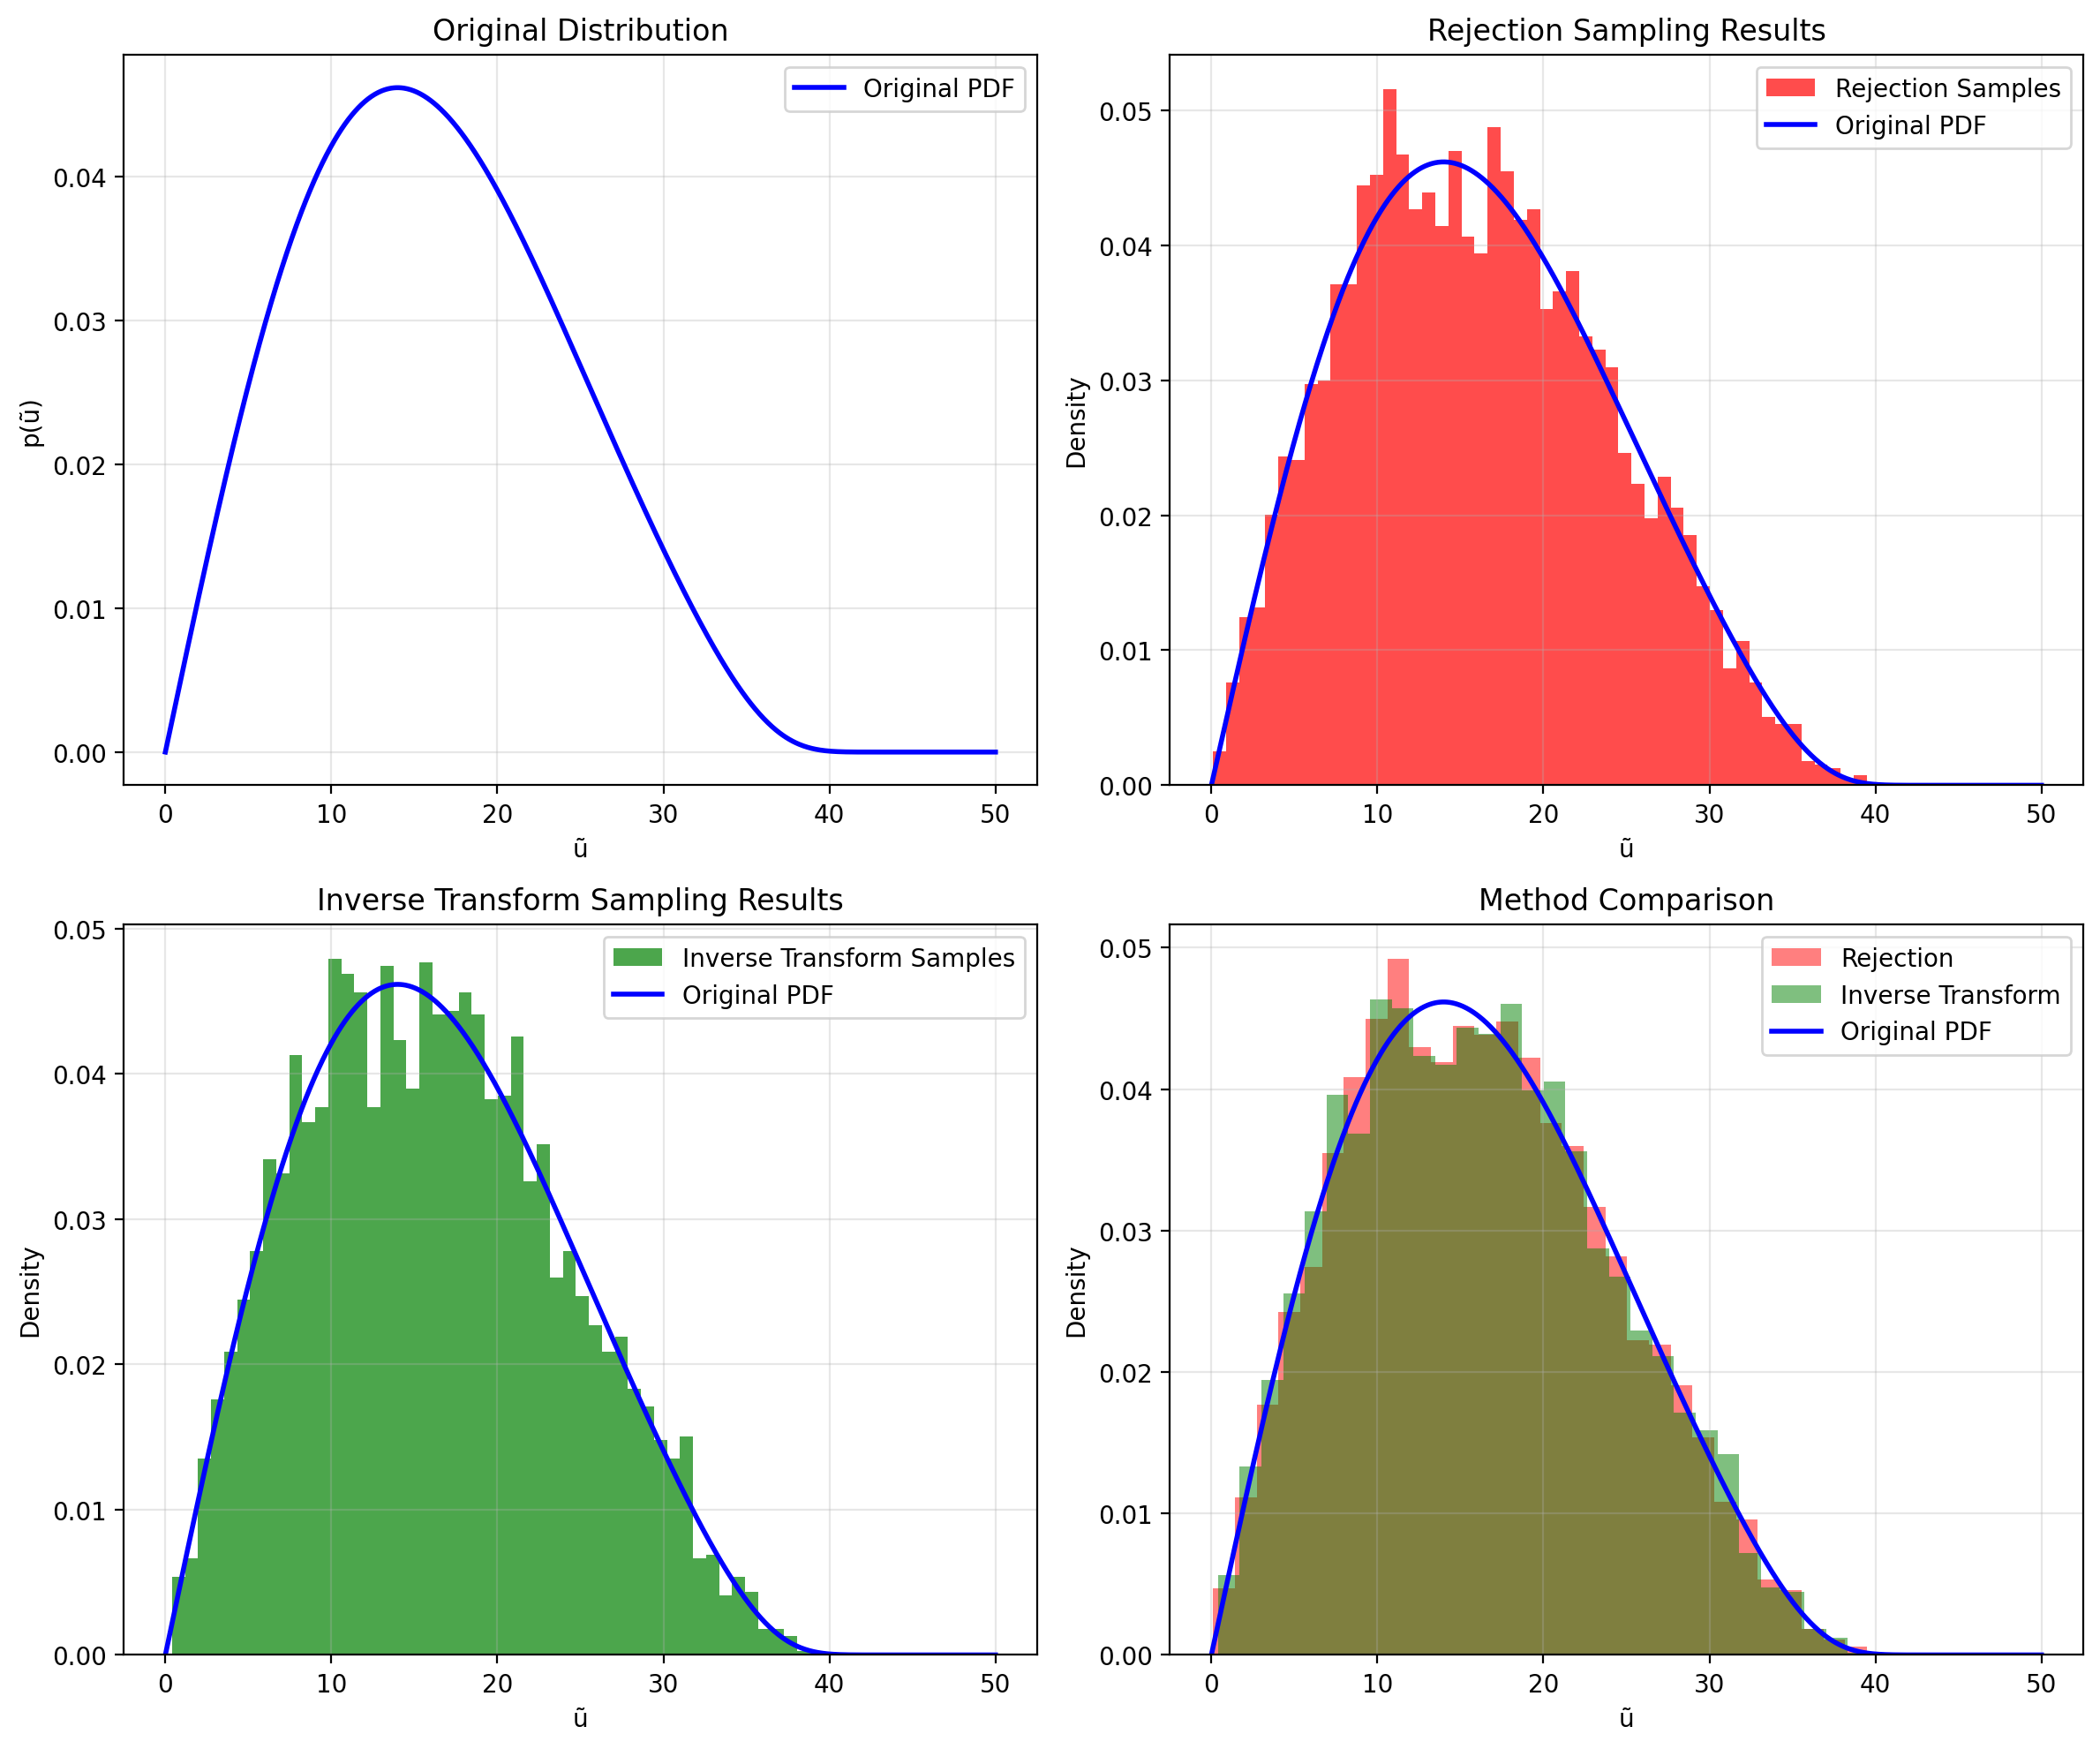


Rejection Sampling Statistics:
  Mean: 16.208
  Std:  7.813
  Min:  0.098
  Max:  39.481

Inverse Transform Sampling Statistics:
  Mean: 16.231
  Std:  7.843
  Min:  0.398
  Max:  39.632


In [12]:
class PU8Sampler:
    def __init__(self, A=5.434e-3, B=2.544e-3, C=3.100, u0=35.67):
        self.A = A
        self.B = B
        self.C = C
        self.u0 = u0
        
    def func_pu_8(self, tilde_u):
        """
        The probability distribution for the normalized parameter ũ = u/√mtot
        """
        return self.A * tilde_u * torch.exp(-1 * (
            self.B * tilde_u**2 + torch.exp((tilde_u - self.u0) / self.C)
        ))
    
    def find_sampling_bounds(self, search_range=(0, 50), num_points=1000):
        """
        Find reasonable bounds for sampling by analyzing the distribution
        """
        tilde_u_range = torch.linspace(search_range[0], search_range[1], num_points)
        pdf_values = self.func_pu_8(tilde_u_range)
        
        # Find where PDF becomes negligible (e.g., < 1e-6 of max value)
        max_pdf = torch.max(pdf_values)
        threshold = max_pdf * 1e-6
        
        valid_indices = pdf_values > threshold
        if torch.any(valid_indices):
            u_min = tilde_u_range[valid_indices][0].item()
            u_max = tilde_u_range[valid_indices][-1].item()
        else:
            u_min, u_max = search_range
            
        # Find maximum value for rejection sampling
        M = max_pdf.item()
        
        return u_min, u_max, M
    
    def rejection_sample(self, n_samples=1000, u_min=None, u_max=None, M=None):
        """
        Sample from the distribution using rejection sampling
        """
        if u_min is None or u_max is None or M is None:
            u_min, u_max, M = self.find_sampling_bounds()
            
        samples = []
        n_attempts = 0
        max_attempts = n_samples * 100  # Prevent infinite loops
        
        while len(samples) < n_samples and n_attempts < max_attempts:
            # Generate candidate from uniform distribution
            u_candidate = torch.rand(1) * (u_max - u_min) + u_min
            
            # Generate uniform random number for acceptance test
            y = torch.rand(1) * M
            
            # Accept if y <= f(u_candidate)
            if y <= self.func_pu_8(u_candidate):
                samples.append(u_candidate.item())
                
            n_attempts += 1
            
        if len(samples) < n_samples:
            print(f"Warning: Only generated {len(samples)} samples out of {n_samples} requested")
            
        return np.array(samples)
    
    def inverse_transform_sample(self, n_samples=1000, u_min=None, u_max=None, num_cdf_points=10000):
        """
        Sample using inverse transform sampling (numerical approximation)
        """
        if u_min is None or u_max is None:
            u_min, u_max, _ = self.find_sampling_bounds()
        
        # Create grid for numerical CDF computation
        u_grid = torch.linspace(u_min, u_max, num_cdf_points)
        pdf_values = self.func_pu_8(u_grid)
        
        # Numerical integration to get CDF
        du = (u_max - u_min) / (num_cdf_points - 1)
        cdf_values = torch.cumsum(pdf_values * du, dim=0)
        cdf_values = cdf_values / cdf_values[-1]  # Normalize to make it a proper CDF
        
        # Generate uniform random numbers
        uniform_samples = torch.rand(n_samples)
        
        # Interpolate to find corresponding u values
        samples = np.interp(uniform_samples.numpy(), cdf_values.numpy(), u_grid.numpy())
        
        return samples

    def sample(self, n_samples=1000, method='rejection'):
        """
        Main sampling function
        
        Args:
            n_samples: Number of samples to generate
            method: 'rejection' or 'inverse_transform'
        """
        if method == 'rejection':
            return self.rejection_sample(n_samples)
        elif method == 'inverse_transform':
            return self.inverse_transform_sample(n_samples)
        else:
            raise ValueError("Method must be 'rejection' or 'inverse_transform'")

# Example usage and validation
def main():
    # Create sampler
    sampler = PU8Sampler()
    
    # Generate samples using both methods
    print("Generating samples...")
    samples_rejection = sampler.sample(n_samples=5000, method='rejection')
    samples_inverse = sampler.sample(n_samples=5000, method='inverse_transform')
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot original distribution
    u_range = np.linspace(0, 50, 1000)
    u_tensor = torch.tensor(u_range, dtype=torch.float32)
    pdf_values = sampler.func_pu_8(u_tensor).detach().numpy()
    
    axes[0, 0].plot(u_range, pdf_values, 'b-', linewidth=2, label='Original PDF')
    axes[0, 0].set_title('Original Distribution')
    axes[0, 0].set_xlabel('ũ')
    axes[0, 0].set_ylabel('p(ũ)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot rejection sampling results
    axes[0, 1].hist(samples_rejection, bins=50, density=True, alpha=0.7, 
                   color='red', label='Rejection Samples')
    axes[0, 1].plot(u_range, pdf_values, 'b-', linewidth=2, label='Original PDF')
    axes[0, 1].set_title('Rejection Sampling Results')
    axes[0, 1].set_xlabel('ũ')
    axes[0, 1].set_ylabel('Density')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot inverse transform sampling results
    axes[1, 0].hist(samples_inverse, bins=50, density=True, alpha=0.7, 
                   color='green', label='Inverse Transform Samples')
    axes[1, 0].plot(u_range, pdf_values, 'b-', linewidth=2, label='Original PDF')
    axes[1, 0].set_title('Inverse Transform Sampling Results')
    axes[1, 0].set_xlabel('ũ')
    axes[1, 0].set_ylabel('Density')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Compare both methods
    axes[1, 1].hist(samples_rejection, bins=30, density=True, alpha=0.5, 
                   color='red', label='Rejection')
    axes[1, 1].hist(samples_inverse, bins=30, density=True, alpha=0.5, 
                   color='green', label='Inverse Transform')
    axes[1, 1].plot(u_range, pdf_values, 'b-', linewidth=2, label='Original PDF')
    axes[1, 1].set_title('Method Comparison')
    axes[1, 1].set_xlabel('ũ')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nRejection Sampling Statistics:")
    print(f"  Mean: {np.mean(samples_rejection):.3f}")
    print(f"  Std:  {np.std(samples_rejection):.3f}")
    print(f"  Min:  {np.min(samples_rejection):.3f}")
    print(f"  Max:  {np.max(samples_rejection):.3f}")
    
    print(f"\nInverse Transform Sampling Statistics:")
    print(f"  Mean: {np.mean(samples_inverse):.3f}")
    print(f"  Std:  {np.std(samples_inverse):.3f}")
    print(f"  Min:  {np.min(samples_inverse):.3f}")
    print(f"  Max:  {np.max(samples_inverse):.3f}")

if __name__ == "__main__":
    main()

In [13]:
# mass_axis = np.arange(0.1, 1.01, 0.01)
# feh_axis = np.arange(-2.16, 0.6, 0.04)


# # Loading the array back
# parsec_cube = np.load('/Volumes/WANG/postgraduate/4.2/IMF/parsec_logAge10_mh_n2p16_06_cube.npy')
# M_grid, F_grid, MG_grid, BR_grid, RP_grid = parsec_cube[0,:,:,], parsec_cube[1,:,:,], parsec_cube[2,:,:,], parsec_cube[3,:,:,], parsec_cube[4,:,:,]


# def get_phot_grid(mass_in, feh_in):
#     # Convert input lists to NumPy arrays
#     mass_in = np.array(mass_in)
#     feh_in = np.array(feh_in)

#     # Find the nearest grid points for each input pair of mass and feh
#     ind_mass = np.argmin(np.abs(mass_in[:, None] - mass_axis), axis=1)
#     ind_feh = np.argmin(np.abs(feh_in[:, None] - feh_axis), axis=1)

#     # Retrieve the corresponding MG, BP, RP values using the grid indices
#     MG_values = MG_grid[ind_feh, ind_mass]
#     BR_values = BR_grid[ind_feh, ind_mass] 
#     RP_values = RP_grid[ind_feh, ind_mass]
#     BP_values = BR_values + RP_values

#     return MG_values, BP_values, RP_values

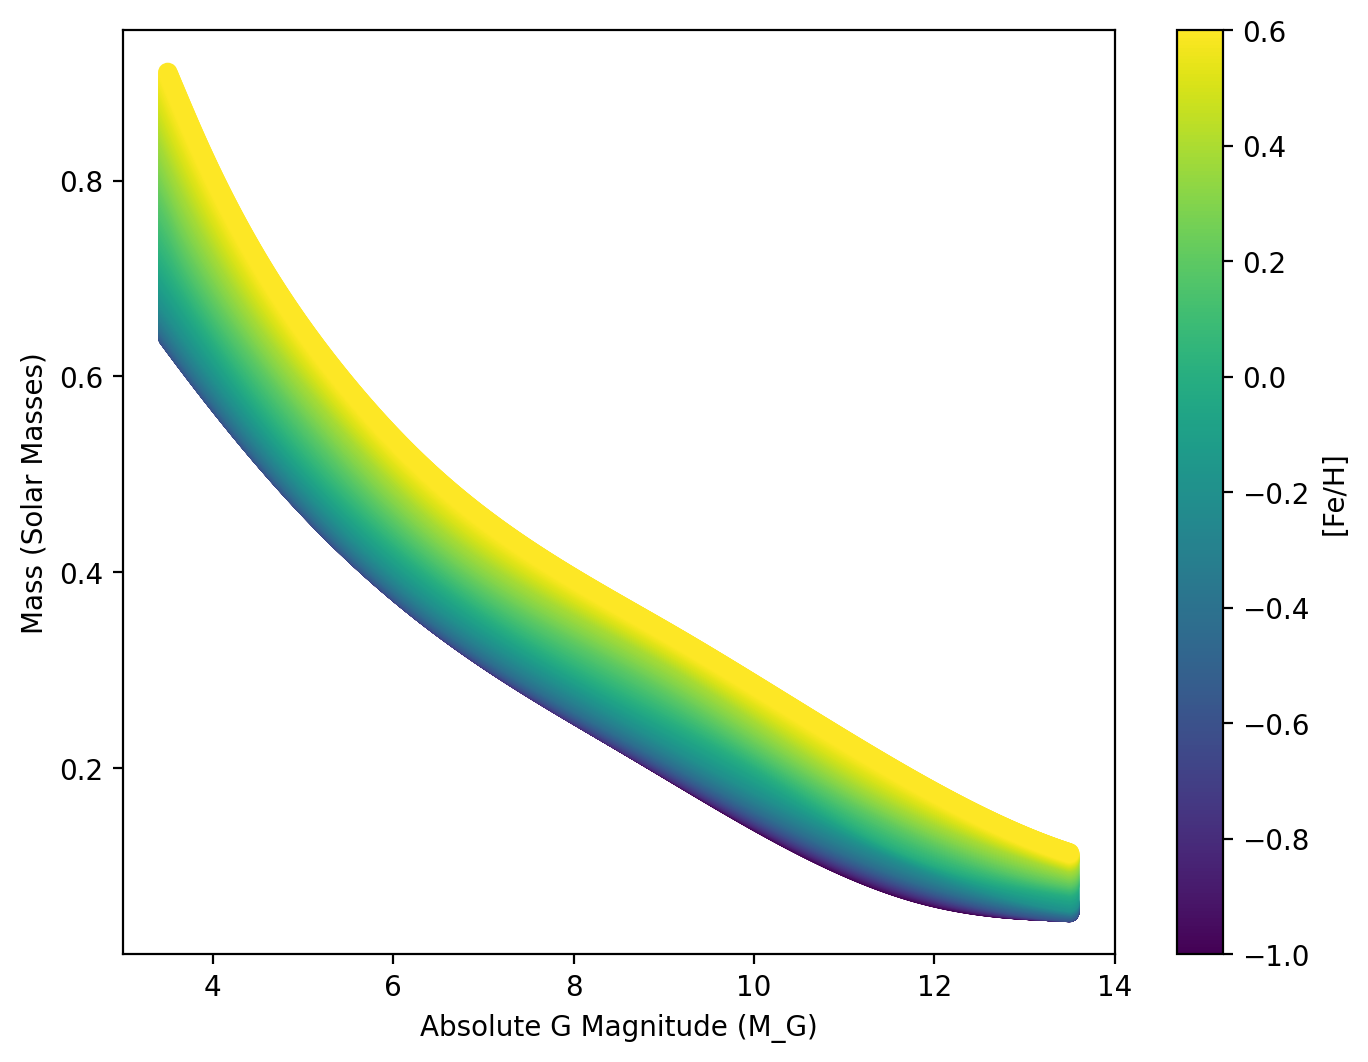

In [15]:
import sys
sys.path.append('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses')

from src.binary_masses.differencepoly_feh import (  # noqa: E402
    DifferencePolyFehMLR,
    IsochroneMassSurfaceModel,
)

order = 2
feh_model = "quadratic2d"
cross_mode = "free"
mass_min=0.05
feh_min = -1
feh_max = 0.6
absg_min = 3.5  
absg_max = 13.5
params = {
    "a0": -0.3,
    "b1": 0.03,
    "a1": -0.02,
    "b2": 0.05,
    "a2": 0.06,
    "c_xy": 0.015
}

iso_data_dir="/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/data/interpolated_mass_data"
iso_surface = IsochroneMassSurfaceModel.from_interpolated_mass_data(
    iso_data_dir,
    mass_min=mass_min,
)

def _absg_to_x_np(absg):
    # Map M_G in [absg_min, absg_max] -> x in [-1, 1] (NumPy).
    return 2.0 * (absg - absg_min) / (absg_max - absg_min) - 1.0


def _feh_to_z_np(feh):
    feh = np.asarray(feh, dtype=float)
    feh = np.clip(feh, feh_min, feh_max)
    return 2.0 * (feh - feh_min) / (feh_max - feh_min) - 1.0


def _log10_delta_np(absg, feh, params):
    absg = np.asarray(absg, dtype=float)
    feh = np.asarray(feh, dtype=float)
    absg, feh = np.broadcast_arrays(absg, feh)

    x = _absg_to_x_np(absg)
    z = _feh_to_z_np(feh)

    a0 = params["a0"]
    b1 = params["b1"]
    a1 = params["a1"]
    b2 = params["b2"]
    a2 = params["a2"]
    c_xy = a2 * b2 if cross_mode == "product" else params.get("c_xy", 0.0)

    return a0 + b1 * z + a1 * x + b2 * (z ** 2) + a2 * (x ** 2) + c_xy * z * x


def mass_from_absg_feh(absg, feh, params):
    absg = np.asarray(absg, dtype=float)
    feh = np.asarray(feh, dtype=float)
    log10_delta = _log10_delta_np(absg, feh, params)
    m_iso = iso_surface.mass_from_absg_mh(absg, feh)
    log10_m = np.log10(np.maximum(m_iso, mass_min)) + log10_delta
    mass = np.power(10.0, log10_m)
    mass = np.where(mass > 0.0, mass, mass_min)
    return mass


absg_grid = np.arange(absg_min, absg_max+0.01, 0.01)
feh_grid = np.arange(feh_min, feh_max+0.01, 0.01)
absg_mesh, feh_mesh = np.meshgrid(absg_grid, feh_grid)
absg_mesh = absg_mesh.flatten()
feh_mesh = feh_mesh.flatten()
mass_mesh = mass_from_absg_feh(absg_mesh, feh_mesh, params)
mass_cube = mass_mesh.reshape(len(feh_grid), len(absg_grid))

plt.figure(figsize=(8, 6))
plt.scatter(absg_mesh, mass_mesh, c=feh_mesh, cmap='viridis')
plt.colorbar(label='[Fe/H]')
plt.xlabel('Absolute G Magnitude (M_G)')
plt.ylabel('Mass (Solar Masses)')
plt.show()


In [16]:
def _prepare_mass_inverter(absg_grid, mass_cube):
    # Prepare monotonic mass->absg mapping per [Fe/H] row.
    order = np.argsort(mass_cube, axis=1)
    mass_sorted = np.take_along_axis(mass_cube, order, axis=1)
    absg_sorted = np.take_along_axis(
        np.broadcast_to(absg_grid, mass_cube.shape),
        order,
        axis=1,
    )
    # enforce strictly increasing mass for interpolation
    eps = 1e-12
    mass_sorted = np.maximum.accumulate(
        mass_sorted + eps * np.arange(mass_sorted.shape[1])[None, :],
        axis=1,
    )
    return mass_sorted, absg_sorted


_mass_sorted, _absg_sorted = _prepare_mass_inverter(absg_grid, mass_cube)


def absg_from_mass_feh_interp(
    mass,
    feh,
    absg_grid,
    feh_grid,
    mass_cube,
    mass_sorted=_mass_sorted,
    absg_sorted=_absg_sorted,
): 
    # Inverse: interpolate absg along mass within two nearest feh rows,
    # then linearly interpolate in feh.
    mass = np.asarray(mass, dtype=float)
    feh = np.asarray(feh, dtype=float)
    mass, feh = np.broadcast_arrays(mass, feh)

    if (
        mass_sorted is None
        or absg_sorted is None
        or mass_sorted.shape != mass_cube.shape
    ):
        mass_sorted, absg_sorted = _prepare_mass_inverter(absg_grid, mass_cube)

    feh = np.clip(feh, feh_grid[0], feh_grid[-1])
    idx1 = np.searchsorted(feh_grid, feh, side="right")
    idx0 = np.clip(idx1 - 1, 0, len(feh_grid) - 1)
    idx1 = np.clip(idx1, 0, len(feh_grid) - 1)

    denom = feh_grid[idx1] - feh_grid[idx0]
    denom = np.where(denom == 0, 1.0, denom)
    w = (feh - feh_grid[idx0]) / denom

    out_absg = np.empty_like(mass, dtype=float)
    it = np.nditer(
        [mass, idx0, idx1, w, out_absg],
        op_flags=[["readonly"], ["readonly"], ["readonly"], ["readonly"], ["writeonly"]],
    )
    for m, i0, i1, ww, o in it:
        i0 = int(i0)
        i1 = int(i1)
        m0 = mass_sorted[i0]
        a0 = absg_sorted[i0]
        m1 = mass_sorted[i1]
        a1 = absg_sorted[i1]
        mt0 = np.clip(float(m), m0[0], m0[-1])
        mt1 = np.clip(float(m), m1[0], m1[-1])
        ab0 = np.interp(mt0, m0, a0)
        ab1 = np.interp(mt1, m1, a1)
        o[...] = (1.0 - ww) * ab0 + ww * ab1

    return out_absg


absg_pred = absg_from_mass_feh_interp(
    [0.1, 0.2, 0.3, 1],
    [0, 0, 0, 0],
    absg_grid,
    feh_grid,
    mass_cube,
)

absg_pred


array([12.35927055, 10.1811624 ,  8.19117351,  3.5       ])

In [17]:
from scipy.stats import truncnorm

file_path='/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/data/jd_msms_single_bic_1kpc_filtered_cmdcut.fits'
wb_table = Table.read(file_path)
# judge if all absg1<absg2 -- mostly yes
s_absg1_lt_absg2 = (wb_table['absg1'] < wb_table['absg2'])
wb_mask = wb_table[s_absg1_lt_absg2]

print(wb_mask['u_sigma'].min(), wb_mask['u_sigma'].max())


# Select the nearest 20 points on the g2-u plane for simulate u_sigma
def simulate_u_with_uncertainty(g2_in, u_in, n_neighbors=5):
    # Convert input lists to NumPy arrays
    g2_in = np.array(g2_in)
    u_in = np.array(u_in)

    # Calculate distances to all points in the dataset
    distances = np.sqrt((wb_mask['phot_g_mean_mag2'][:, None] - g2_in[None, :])**2 + 
                        (wb_mask['u'][:, None] - u_in[None, :])**2)
    print(distances.shape)
    # Find indices of the nearest neighbors, provide maximum distance limit to avoid very far points
    nearest_indices = np.argsort(distances, axis=0)[:n_neighbors, :]

    # Retrieve the corresponding u_sigma values
    u_sigma = (wb_mask['u_sigma'])[nearest_indices]
    print(u_sigma.shape)

    # Simulate new u values by adding truncate Gaussian noise based on u_sigma
    simulated_u = []
    mean_u_sigma = np.mean(u_sigma, axis=0)
    print(mean_u_sigma.shape)
    
    for i in range(len(g2_in)):
        if mean_u_sigma[i] > 0:
            a = (0.0 - u_in[i]) / mean_u_sigma[i] # scipy.stats.truncnorm 的 a/b 是标准化后的截断界，也就是 (x_min - loc)/scale，不是直接给 x_min
            u_obs = truncnorm.rvs(a, np.inf, loc=u_in[i], scale=mean_u_sigma[i])
            simulated_u.append(u_obs)
        else:
            simulated_u.append(np.nan)  # If no neighbors found, give NaN

    return mean_u_sigma, np.array(simulated_u)

0.013000700674573882 52.18302926138707


In [18]:
from astropy.table import vstack as at_vstack
from scipy.stats import truncnorm
from numpy.random import choice

import sys
sys.path.append('/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects')
import IMF.IMFpackage.IMFspl as spl


def simulate_mock_data(N, d, 
                       mass_range=[0.1, 1.0], g_range=[8, 18],
                       f_outlier=0.1, u_outlier=35, sigma_outlier=15,
                       a=None, e_alpha=None):
    """
    Simulate astrometry (u) and photometry (BP-RP, M_g) for the mock data.
    Prepare the mock data:
        self.bprp_1 = (self.wb_table['bp_rp1'].data).astype(np.float32)
        self.absg_1 = (self.wb_table['absg1'].data).astype(np.float32)
        self.bprp_2 = (self.wb_table['bp_rp2'].data).astype(np.float32)
        self.absg_2 = (self.wb_table['absg2'].data).astype(np.float32)
        self.u = (self.wb_table['u'].data).astype(np.float32)
        self.u_sigma = self.wb_table['u_sigma'].astype(np.float32)
        self.norm_factor = (self.wb_table['norm_factor'].data).astype(np.float32)
    
    Parameters:
    -----------
    e_values : array-like, optional
        Eccentricity values to simulate. Default: 0 to 1 with step 0.01
    N_binaries : int
        Number of binaries to simulate for each eccentricity
    mtot : float
        Total mass of the binary system in solar masses
    
    Returns:
    --------
    dict : Dictionary containing eccentricity values, u_tilde arrays, and distributions
    """
    
    results = {
        'u_values': {},
        'u_tilde_values': {},
        'absg1': {},
        'absg2': {},
        'bp_rp1': {},
        'bp_rp2': {},
        'feh': {},
        'm1': {},
        'm2': {}
    }

    # choose N mtot from m_lst
    # m1 = np.random.uniform(mass_range[0], mass_range[1], size=N)
    # m2 = np.random.uniform(mass_range[0], mass_range[1], size=N)
    m1 = spl.draw_from_IMF(N, m_min=mass_range[0], m_max=mass_range[1])
    m2 = spl.draw_from_IMF(N, m_min=mass_range[0], m_max=mass_range[1])
    feh = np.random.uniform(-1, 0.6, size=N)  # Draw metallicity from MDF
    mtot = m1 + m2

    # absg1, bp1, rp1 = get_phot_grid(m1, feh)
    # absg2, bp2, rp2 = get_phot_grid(m2, feh)
    # bprp1 = bp1-rp1
    # bprp2 = bp2-rp2
    absg1 = absg_from_mass_feh_interp(m1, feh, absg_grid, feh_grid, mass_cube)
    absg2 = absg_from_mass_feh_interp(m2, feh, absg_grid, feh_grid, mass_cube)
    g1 = absg1 + 5 * np.log10(d) - 5
    g2 = absg2 + 5 * np.log10(d) - 5

    # judge primary and secondary
    mask = (g1 < g2)
    print(g1)
    gpr = np.zeros(len(g1))
    gsd = np.zeros(len(g2))
    gpr[mask] = g1[mask]
    gpr[~mask] = g2[~mask]
    gsd[mask] = g2[mask]
    gsd[~mask] = g1[~mask]

    # Apply g magnitude cuts
    valid_indices = (gsd >= g_range[0]) & (gsd <= g_range[1]) & (absg1 >= 3.6)
    m1 = m1[valid_indices]
    m2 = m2[valid_indices]
    feh = feh[valid_indices]
    absg1 = absg1[valid_indices]
    absg2 = absg2[valid_indices]
    # bprp1 = bprp1[valid_indices]
    # bprp2 = bprp2[valid_indices]
    d = d[valid_indices]
    mtot = mtot[valid_indices]

    g1 = g1[valid_indices]
    g2 = g2[valid_indices]
    gsd = gsd[valid_indices]

    # N binaries to simulate
    N_binaries = len(m1)

    # Create binaries with fixed eccentricity
    # Create sampler
    sampler = PU8Sampler()
    
    # Generate samples using both methods
    print("Generating samples...")
    u_tilde_values = sampler.sample(n_samples=N_binaries, method='inverse_transform')
    # substitute inliner u_values with outluer u_values
    N_outliers = int(N_binaries * f_outlier)
    outlier_indices = choice(np.arange(N_binaries), size=N_outliers, replace=False)
    outlier_mask = np.zeros(N_binaries, dtype=bool)
    outlier_mask[outlier_indices] = True
    
    # truncate Gaussian to positive values
    a = (0 - u_outlier) / sigma_outlier
    u_tilde_values[outlier_indices] = truncnorm.rvs(a, b=np.inf, loc=u_outlier, scale=sigma_outlier, size=N_outliers)

    # Calculate u in units of km/s * AU^0.5
    u0_values = u_tilde_values * np.sqrt(mtot)
    u_sigma_values, u_values = simulate_u_with_uncertainty(gsd, u0_values, n_neighbors=5)

    # print(u_sigma_values[np.where(u_sigma_values==max(u_sigma_values))])
    # print(u_values[np.where(u_sigma_values==max(u_sigma_values))])

    results['u0'] = u0_values
    results['u_sigma'] = u_sigma_values
    results['u'] = u_values
    results['absg1'] = absg1
    results['absg2'] = absg2
    # results['bp_rp1'] = bprp1
    # results['bp_rp2'] = bprp2
    results['feh'] = feh
    results['m1'] = m1
    results['m2'] = m2
    results['d'] = d
    results['g1'] = g1
    results['g2'] = g2
    results['is_outlier'] = outlier_mask

    print(f"Simulated {N_binaries} binaries with a={a}, e_alpha={e_alpha}")
    
    return results



data = pd.read_csv('/Volumes/WANG/postgraduate/4.2/Dyn/data/gaiaedr3mock_distance.csv')
data['distance_pc'] = 1000. / data['parallax']

for i in range(5):
    N_binaries = 10000
    d = choice(data['distance_pc'], size=N_binaries, replace=True)
    results = simulate_mock_data(N=N_binaries, d=d, mass_range=[0.05, 1.], g_range=[8, 18],)
    # 保证在测量的星等内，每个金属丰度的质量数据都有覆盖，此模拟mlr的 0.1-2.5 Msun 对应绝对星等 4-11.5

    table = Table()
    table['u0'] = results['u0']
    table['u'] = results['u']
    table['u_sigma'] = results['u_sigma']  # Assuming a constant fractional uncertainty of 0.1% for u
    table['absg1'] = results['absg1']
    table['absg2'] = results['absg2']
    # table['bp_rp1'] = results['bp_rp1']
    # table['bp_rp2'] = results['bp_rp2']
    table['feh'] = results['feh']
    table['m1'] = results['m1']
    table['m2'] = results['m2']
    table['d'] = results['d']
    table['g1'] = results['g1']
    table['g2'] = results['g2']
    table['is_outlier'] = results['is_outlier']

    # contatenate table
    table_tot = table if i == 0 else at_vstack([table_tot, table], join_type="outer")

[21.97339634 23.19959062 20.46026203 ... 17.8666456  21.88330212
 18.19634017]
Generating samples...
(40206, 1160)
(5, 1160)
(1160,)
Simulated 1160 binaries with a=-2.3333333333333335, e_alpha=None
[13.56245687 21.44284111 20.86536688 ... 23.39033665 21.32965889
 21.30311046]
Generating samples...
(40206, 1240)
(5, 1240)
(1240,)
Simulated 1240 binaries with a=-2.3333333333333335, e_alpha=None
[15.54064526 16.03306788 17.11026952 ... 20.24643829 19.16369491
 22.03676738]
Generating samples...
(40206, 1178)
(5, 1178)
(1178,)
Simulated 1178 binaries with a=-2.3333333333333335, e_alpha=None
[23.15491614 17.79168609 18.38436289 ... 15.18364898 21.89403873
 22.73271696]
Generating samples...
(40206, 1155)
(5, 1155)
(1155,)
Simulated 1155 binaries with a=-2.3333333333333335, e_alpha=None
[21.57006161 15.98440023 16.32821946 ... 21.67249569 22.10645321
 13.19701419]
Generating samples...
(40206, 1249)
(5, 1249)
(1249,)
Simulated 1249 binaries with a=-2.3333333333333335, e_alpha=None


In [19]:
print(np.mean(table_tot['is_outlier']))

# write to astropy table and save as fits file
data_path = '/Users/ytwang/Library/CloudStorage/OneDrive-Personal/Files/postgraduate/PyProjects/Dyn/bayesian-binary-masses/data/mock_data_efuncu_galaxiad_imfm_unifmh_obserr_outlier_diff2d_mg35_135.fits'
table_tot.write(data_path, overwrite=True, format='fits')

0.09963223002340355


# 2. Mock data test

In [ ]:
#!/usr/bin/env python3
"""
Continuous-Metallicity Difference-Polynomial Fitting Example

This example demonstrates how to fit a mass-luminosity relation (MLR) while
treating metallicity as a continuous covariate (one metallicity per system),
instead of binning by [Fe/H].

Model:
    log10 m_dyn(M_G, MH) = log10 m_iso(M_G, MH) + delta

    delta = a0 + b1*z + a1*x + b2*z^2 + a2*x^2 + c*z*x

where the baseline m_iso is taken from the interpolated isochrone grid and
x, z are rescaled M_G and [Fe/H].

Author: Yutong Wang
"""

import os
import sys

import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from numpy.random import choice


# Add the package to Python path (notebook-compatible)
notebook_dir = os.path.abspath('')
sys.path.insert(0, os.path.join(notebook_dir, "..", ".."))

from binary_masses.differencepoly_feh import (  # noqa: E402
    DifferencePolyFehMLR,
    DifferencePolyFehMassAbsgModel,
    IsochroneMassSurfaceModel,
)


def test_differencepoly_feh_model(
    data,
    *,
    output_dir,
    uncertainty_model="rice",
    feh_column="feh",
    feh_min=None,
    feh_max=None,
    order=2,
    absg_min=None,
    absg_max=None,
    mass_min=0.05,
    mass_max=2.0,
    deriv_penalty_strength=10.0,
    feh_monotone_strength=0.0,
    monotone_n_feh=5,
    coeff_prior_scale=5.0,
    feh_coeff_prior_scale=1.0,
    f_outlier_init=0.1,
    outlier_u0_init=35,
    outlier_sigma_init=15,
    outlier_kappa=None,
    outlier_kappa_scale=0.05,
    fit_outlier_params=False,
    param_truths=None,
    truth_model=None,
    plot_corner_truths=True,
    num_warmup=800,
    num_samples=2000,
    num_chains=2,
    seed=34,
    iso_data_dir="data/interpolated_mass_data",
    feh_plot_values=None,
    feh_model="quadratic2d",
    cross_mode="product",
    quad_mode=None,
    quad_mask=None,
):
    """
    Fit the DifferencePolyFehMLR model on all data (no metallicity binning).

    Notes
    -----
    - The isochrone baseline uses MH from the interpolated grid.
      If your system metallicity is [Fe/H], you are implicitly assuming MH approx [Fe/H].
    """
    print("" + "=" * 60)
    print("TESTING DIFFERENCE-POLY WITH CONTINUOUS METALLICITY")
    print("=" * 60)

    if feh_column not in data.colnames:
        raise ValueError(f"Metallicity column {feh_column!r} not found in data.")

    print(f"Data contains {len(data)} systems. Calculating ranges...")
    def _robust_range(values, *, lo=1.0, hi=99.0):
        values = np.asarray(values, dtype=float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            raise ValueError("No finite values available to infer plotting range.")
        return np.nanpercentile(values, [lo, hi])

    absg_all = np.concatenate([np.asarray(data["absg1"]), np.asarray(data["absg2"])])
    absg_lo, absg_hi = _robust_range(absg_all)
    plot_absg_min = absg_lo if absg_min is None else absg_min
    plot_absg_max = absg_hi if absg_max is None else absg_max
    if plot_absg_max <= plot_absg_min:
        raise ValueError(f"Invalid plotting absg range: [{plot_absg_min}, {plot_absg_max}].")

    feh_lo, feh_hi = _robust_range(data[feh_column])
    plot_feh_min = feh_lo if feh_min is None else feh_min
    plot_feh_max = feh_hi if feh_max is None else feh_max
    if plot_feh_max <= plot_feh_min:
        raise ValueError(f"Invalid plotting feh range: [{plot_feh_min}, {plot_feh_max}].")

    os.makedirs(output_dir, exist_ok=True)


    print("1. Loading isochrone mass surface...")
    iso_surface = IsochroneMassSurfaceModel.from_interpolated_mass_data(
        iso_data_dir,
        mass_min=mass_min,
    )

    print("Setting up truth model...")
    truth_model_auto = truth_model
    if truth_model_auto is None and param_truths is not None:
        truth_absg_min = plot_absg_min if absg_min is None else absg_min
        truth_absg_max = plot_absg_max if absg_max is None else absg_max
        truth_feh_min = plot_feh_min if feh_min is None else feh_min
        truth_feh_max = plot_feh_max if feh_max is None else feh_max
        truth_model_auto = DifferencePolyFehMassAbsgModel(
            order=order,
            absg_min=truth_absg_min,
            absg_max=truth_absg_max,
            mass_min=mass_min,
            pivot=(truth_absg_min + truth_absg_max) / 2.0,
            deriv_penalty_strength=0.0,
            feh_monotone_strength=0.0,
            isochrone_surface_model=iso_surface,
            feh_min=truth_feh_min,
            feh_max=truth_feh_max,
            feh_model=feh_model,
            cross_mode=cross_mode,
        )


    print("2. Initializing DifferencePolyFehMLR fitter...")
    fitter = DifferencePolyFehMLR(
        order=order,
        isochrone_surface_model=iso_surface,
        feh_min=feh_min,
        feh_max=feh_max,
        mass_min=mass_min,
        mass_max=mass_max,
        absg_min=absg_min,
        absg_max=absg_max,
        uncertainty_model=uncertainty_model,
        f_outlier=f_outlier_init,
        outlier_u0=outlier_u0_init,
        outlier_sigma=outlier_sigma_init,
        outlier_kappa=outlier_kappa,
        outlier_kappa_scale=outlier_kappa_scale,
        fit_outlier_params=fit_outlier_params,
        param_truths=None,
        deriv_penalty_strength=deriv_penalty_strength,
        feh_monotone_strength=feh_monotone_strength,
        coeff_prior_scale=coeff_prior_scale,
        feh_coeff_prior_scale=feh_coeff_prior_scale,
        monotone_n_feh=monotone_n_feh,
        feh_model=feh_model,
        cross_mode=cross_mode,
    )

    if plot_corner_truths and param_truths is not None:
        expected = fitter.poly_model.n_params + (3 if fit_outlier_params else 0)
        if len(param_truths) == expected:
            fitter.param_truths = list(param_truths)
        else:
            print(
                f"Skipping corner truths (expected {expected} values, got {len(param_truths)})."
            )

    print("3. Setting data...")
    fitter.set_data(
        u_values=data["u"],
        u_sigma_values=data["u_sigma"] if "u_sigma" in data.colnames else None,
        # u_values=data["u0"],
        # u_sigma_values=None,
        absg1_values=data["absg1"],
        absg2_values=data["absg2"],
        feh_values=data[feh_column],
        outlier_kappa=outlier_kappa,
        outlier_kappa_scale=outlier_kappa_scale,
    )

    print("4. Running MCMC...")
    outlier_tag = "outlierfit" if fit_outlier_params else "outlierfixed"
    suffix = (
        f"_model-differencepolyfeh_unc-{uncertainty_model}"
        f"_fehcont_{outlier_tag}_order{order}"
        f"_feh[{plot_feh_min:+.2f},{plot_feh_max:+.2f}]"
        f"_kappas{outlier_kappa_scale:.3f}" if outlier_kappa is not None else ""
    )

    fitter.run_numpyro(
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        seed=seed,
        quad_mode=quad_mode,
        quad_mask=quad_mask,
    )

    print("5. Saving samples and plots...")
    np.savetxt(os.path.join(output_dir, f"mcmc{suffix}.txt"), fitter.samples)
    fitter.plot_results(output_dir=output_dir, output_suffix=suffix)

    feh_ref = float(np.nanmedian(np.array(data[feh_column], dtype=float)))
    absg_curve = np.linspace(plot_absg_min, plot_absg_max, 400)
    # iso_mass_curve = iso_surface.mass_from_absg_mh(absg_curve, feh_ref)

    # fitter.plot_fitting_results(
    #     data=data,
    #     output_dir=output_dir,
    #     output_suffix=suffix,
    #     isochrone_curve_data_feh={
    #         "absg": absg_curve,
    #         "mass": iso_mass_curve,
    #     },
    #     iso_colname_dict={"absg": "absg", "mass": "mass", "feh": "MH"},
    # )

    feh_plot_values = (
        np.linspace(plot_feh_min, plot_feh_max, 5)
        if feh_plot_values is None
        else np.array(feh_plot_values, dtype=float)
    )
    feh_plot_values = feh_plot_values[np.isfinite(feh_plot_values)]
    if feh_plot_values.size == 0:
        raise ValueError("feh_plot_values must contain at least one finite value.")

    plot_mlr_multi_feh(
        fitter=fitter,
        iso_surface=iso_surface,
        feh_values=feh_plot_values,
        absg_min=plot_absg_min,
        absg_max=plot_absg_max,
        output_dir=output_dir,
        output_suffix=suffix,
        truths=param_truths,
        truth_model=truth_model_auto,
    )

    print("6. Done.")
    print(f"   Reference metallicity for isochrone curve: [Fe/H] approx {feh_ref:+.2f}")
    print(f"   Saved: {os.path.join(output_dir, f'mcmc{suffix}.txt')}")
    return fitter


def plot_mlr_multi_feh(
    *,
    fitter,
    iso_surface,
    feh_values,
    absg_min,
    absg_max,
    output_dir,
    output_suffix,
    truths=None,
    truth_model=None,
):
    if fitter.samples is None or fitter.samples.size == 0:
        print("No samples available for multi-metallicity plot.")
        return

    if fitter.fit_outlier_params:
        coeff_samples = fitter.samples[:, :-3]
    else:
        coeff_samples = fitter.samples

    n_coeff = coeff_samples.shape[1]
    truth_coeffs = None
    truth_mass_fn = None

    if truths is not None:
        truth_arr = np.asarray(truths, dtype=float).reshape(-1)

        if fitter.fit_outlier_params and truth_arr.size == n_coeff + 3:
            truth_arr = truth_arr[:n_coeff]

        if truth_model is not None:
            if not hasattr(truth_model, "mass_from_absg_feh"):
                raise ValueError("truth_model must implement mass_from_absg_feh().")
            truth_coeffs = truth_arr
            truth_mass_fn = truth_model.mass_from_absg_feh
        elif truth_arr.size == n_coeff:
            truth_coeffs = truth_arr
            truth_mass_fn = fitter.mass_from_absg_feh
        elif truth_arr.size < n_coeff:
            truth_coeffs = np.pad(truth_arr, (0, n_coeff - truth_arr.size), constant_values=0.0)
            truth_mass_fn = fitter.mass_from_absg_feh
        elif fitter.poly_model.feh_model == "quadratic2d" and truth_arr.size in (5, 6):
            inferred_cross_mode = "free" if truth_arr.size == 6 else "product"
            truth_model_auto = DifferencePolyFehMassAbsgModel(
                order=2,
                absg_min=fitter.poly_model.absg_min,
                absg_max=fitter.poly_model.absg_max,
                mass_min=fitter.poly_model.mass_min,
                pivot=fitter.poly_model.pivot,
                deriv_penalty_strength=fitter.poly_model.deriv_penalty_strength,
                feh_monotone_strength=fitter.poly_model.feh_monotone_strength,
                isochrone_surface_model=fitter.iso_surface,
                feh_min=fitter.poly_model.feh_min,
                feh_max=fitter.poly_model.feh_max,
                feh_model="quadratic2d",
                cross_mode=inferred_cross_mode,
            )
            truth_coeffs = truth_arr
            truth_mass_fn = truth_model_auto.mass_from_absg_feh
        else:
            print(
                "Truth coefficients length does not match fitted model; skipping truth curves."
            )

    num_samples = min(2000, len(coeff_samples))
    if num_samples < len(coeff_samples):
        # rng = np.random.default_rng(42)
        indices = choice(len(coeff_samples), size=num_samples, replace=False)
        coeff_samples = coeff_samples[indices]

    absg_range = np.linspace(absg_min, absg_max, 600)
    feh_values = np.asarray(feh_values, dtype=float)
    feh_values = np.sort(feh_values[np.isfinite(feh_values)])
    if feh_values.size == 0:
        raise ValueError("feh_values must contain at least one finite value.")

    cmap = plt.cm.viridis
    norm = plt.Normalize(feh_values.min(), feh_values.max())

    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.07)
    ax_main = fig.add_subplot(gs[0])
    ax_resid = fig.add_subplot(gs[1], sharex=ax_main)
    ax_main.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    for feh in feh_values:
        iso_mass = None
        color = cmap(norm(feh))
        masses = fitter.mass_from_absg_feh(absg_range, feh, coeff_samples)
        lower, median, upper = np.percentile(masses, [16, 50, 84], axis=0)

        ax_main.fill_between(absg_range, lower, upper, color=color, alpha=0.18)
        ax_main.plot(absg_range, median, color=color, linewidth=2)

        if iso_surface is not None:
            iso_mass = iso_surface.mass_from_absg_mh(absg_range, feh)
            ax_main.plot(absg_range, iso_mass, color=color, linewidth=1, linestyle="--", alpha=0.8)

        if truth_coeffs is not None and truth_mass_fn is not None:
            true_masses = truth_mass_fn(absg_range, feh, truth_coeffs)
            ax_main.plot(absg_range, true_masses, color=color, linewidth=3, linestyle=":", alpha=0.8)
            residual = median - true_masses
            resid_lower = lower - true_masses
            resid_upper = upper - true_masses
            ax_resid.fill_between(absg_range, resid_lower, resid_upper, color=color, alpha=0.15)
            ax_resid.plot(absg_range, residual, color=color, linewidth=1.5)
        elif iso_mass is not None:
            residual = median - iso_mass
            resid_lower = lower - iso_mass
            resid_upper = upper - iso_mass
            ax_resid.fill_between(absg_range, resid_lower, resid_upper, color=color, alpha=0.15)
            ax_resid.plot(absg_range, residual, color=color, linewidth=1.5)

    legend_lines = [
        Line2D([0], [0], color="black", linewidth=2, linestyle="-"),
        Line2D([0], [0], color="black", linewidth=1.5, linestyle="--"),
    ]
    legend_labels = [r"Fit median (band = 1$\sigma$)", "Isochrone"]
    if truth_coeffs is not None and truth_mass_fn is not None:
        legend_lines.append(Line2D([0], [0], color="black", linewidth=3, linestyle=":"))
        legend_labels.append("Truth")
    ax_main.legend(legend_lines, legend_labels, fontsize=10, loc="best")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_main, ax_resid], pad=0.02, location="right")
    cbar.set_label("[Fe/H]", rotation=270, labelpad=12)

    ax_main.set_ylabel("Mass [$M_{\odot}$]", fontsize=12)
    ax_main.set_xlim(absg_min, absg_max)
    ax_main.set_ylim(fitter.mass_min * 0.8, fitter.mass_max * 1.2)
    ax_main.set_yscale("log")
    ax_main.invert_xaxis()
    ax_resid.set_xlim(ax_main.get_xlim())
    fig.align_xlabels([ax_main, ax_resid])

    ax_resid.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    resid_label = "Derived $-$ Truth [$M_{\odot}$]" if truth_coeffs is not None else "Derived $-$ Isochrone [$M_{\odot}$]"
    ax_resid.set_ylabel(resid_label, fontsize=11)
    ax_resid.set_xlim(absg_min, absg_max)
    ax_resid.set_xlabel("$M_{\mathrm{G}}$ [mag]", fontsize=12)

    if truth_coeffs is None and iso_surface is None:
        ax_resid.text(
            0.5,
            0.5,
            "Truth coefficients not provided",
            transform=ax_resid.transAxes,
            ha="center",
            va="center",
            color="gray",
            fontsize=10,
        )

    # invert x-axis for both plots
    ax_main.invert_xaxis()
    ax_resid.invert_xaxis()
    fig.tight_layout()

    os.makedirs(output_dir, exist_ok=True) if output_dir else None
    filename = f"fit_multifeh{output_suffix}.png"
    fig.savefig(os.path.join(output_dir, filename), dpi=300)
    plt.close(fig)




def main():
    print("=" * 70)
    print("Continuous-Metallicity DifferencePoly MLR Example")
    print("=" * 70)

    print("1. Importing data with metallicity...")
    data_path = "/home/wyt/Dyn/Dynamical-masses/data/mock_data_efuncu_galaxiad_imfm_unifmh_obserr_outlier_diff2d_mg35_135_2.fits"
    data = Table.read(data_path)

    # randomly choose 5000 systems for faster testing
    # rng = np.random.default_rng(12)
    # indices = choice(len(data), size=5000, replace=False)
    # data = data[indices]

    print(f"   Using {len(data)} systems")

    output_dir = "/home/wyt/Dyn/Dynamical-masses/results/test_diffpoly2d_feh_mock3"

    # Pick the metallicity column that exists in your table.
    # Common choices in this repo: "feh" or "feh_jcaps_1".
    feh_column = "feh"
    if feh_column not in data.colnames and "feh_jcaps_1" in data.colnames:
        feh_column = "feh_jcaps_1"

    test_differencepoly_feh_model(
        data,
        output_dir=output_dir,
        uncertainty_model="gaussian",
        feh_column=feh_column,
        feh_min=-1,
        feh_max=0.6,
        order=2,
        absg_min=3.5,
        absg_max=13.5,
        mass_min=0.05,
        mass_max=2.0,
        deriv_penalty_strength=0,
        feh_monotone_strength=0,
        monotone_n_feh=5,
        coeff_prior_scale=3.0,
        feh_coeff_prior_scale=3.0,
        f_outlier_init=0.1,
        outlier_u0_init=35,
        outlier_sigma_init=15,
        outlier_kappa=None,
        outlier_kappa_scale=1,
        fit_outlier_params=True,
        param_truths=[-0.2, 0.03, -0.02, 0.05, -0.06, -0.02, 0.1, 35, 15],
        num_warmup=500,
        num_samples=5000,
        num_chains=1,
        seed=15,
        iso_data_dir="/home/wyt/Dyn/Dynamical-masses/data/interpolated_mass_data",
        feh_plot_values=[-1.0, -0.5, 0.0, 0.3, 0.6],
        feh_model="quadratic2d",
        cross_mode="free",
        quad_mode="full",
    )

    print("Generated files (prefix):")
    print(f"  - {output_dir}/mcmc_model-differencepolyfeh_*.txt")
    print(f"  - {output_dir}/corner_model-differencepolyfeh_*.png")
    print(f"  - {output_dir}/fit_model-differencepolyfeh_*.png")
    print("Continuous-metallicity example completed successfully!")


if __name__ == "__main__":
    main()

Continuous-Metallicity DifferencePoly MLR Example
1. Importing data with metallicity...
   Using 7435 systems
TESTING DIFFERENCE-POLY WITH CONTINUOUS METALLICITY
Data contains 7435 systems. Calculating ranges...
1. Loading isochrone mass surface...
Setting up truth model...
2. Initializing DifferencePolyFehMLR fitter...
3. Setting data...
4. Running MCMC...
NumPyro: running on GPU backend (Tesla V100S-PCIE-32GB, Tesla V100S-PCIE-32GB).


sample:  87%|████████▋ | 4774/5500 [02:24<00:19, 37.11it/s, 31 steps of size 2.65e-01. acc. prob=0.89]

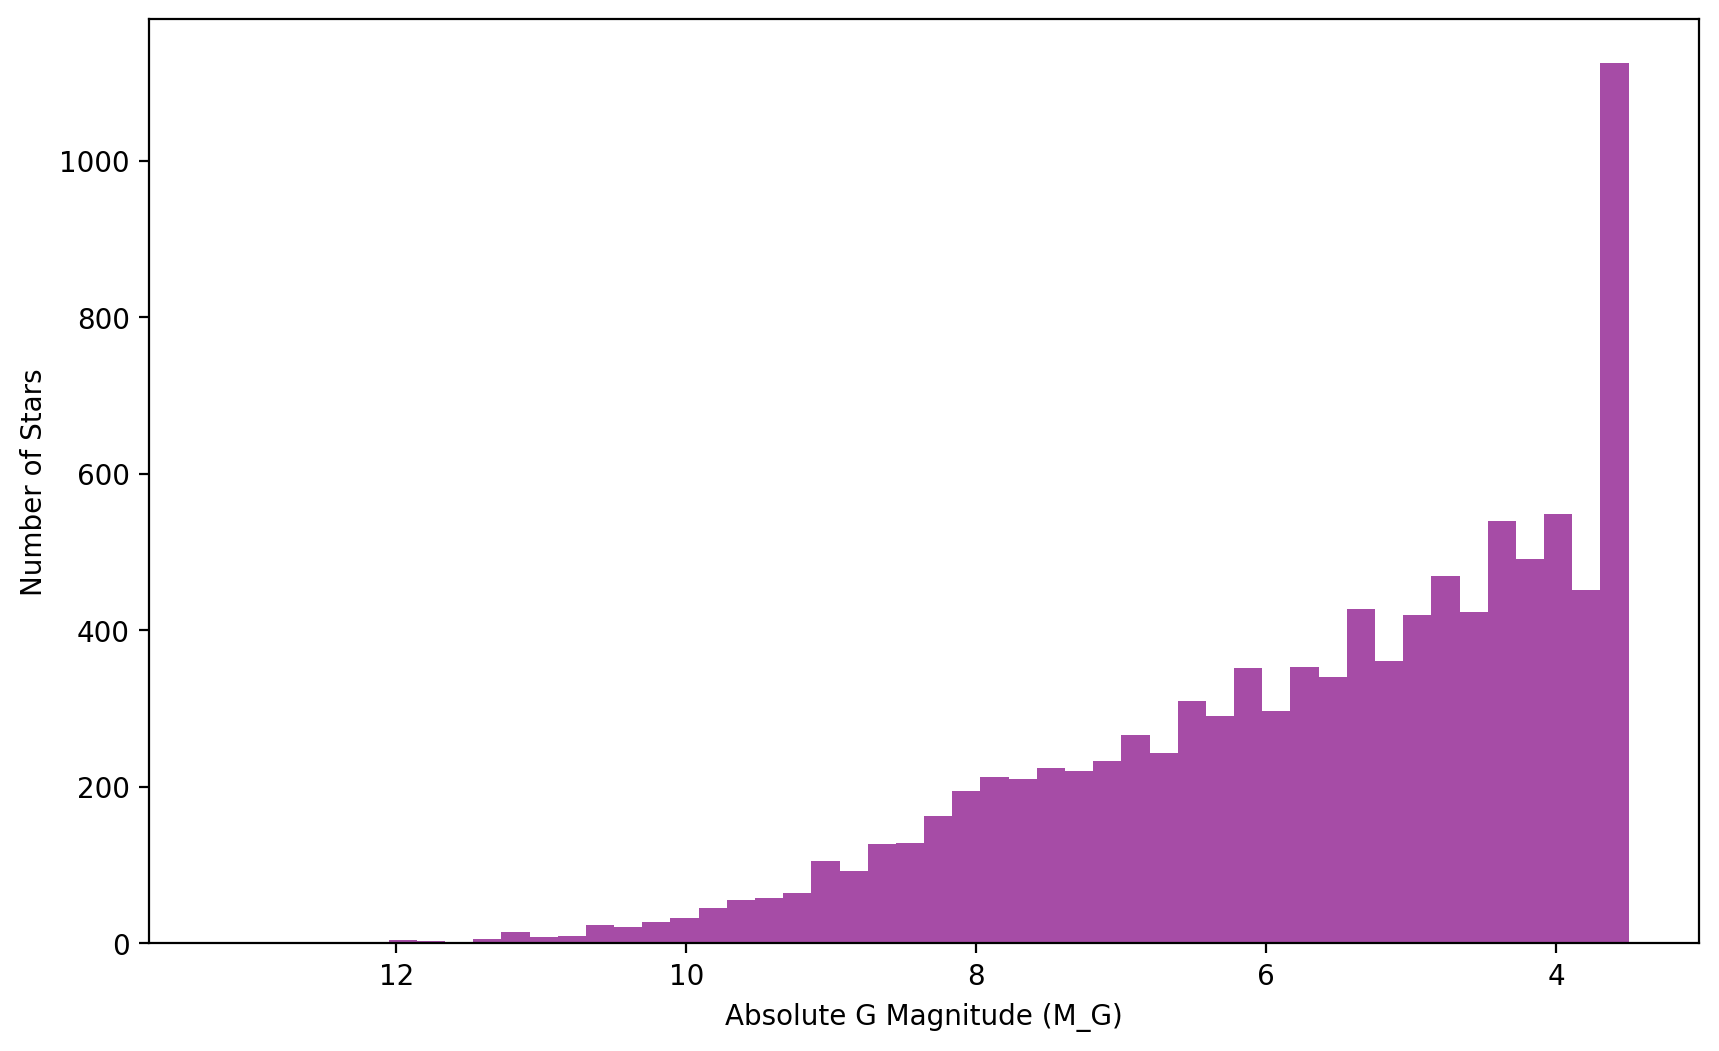

In [ ]:
# Number distribution function of MG
data_path = "/home/wyt/Dyn/Dynamical-masses/data/mock_data_efuncu_galaxiad_unifm_unifmh_obserr_outlier_diffmlr.fits"
data = Table.read(data_path)

# randomly choose 5000 systems for faster testing
# rng = np.random.default_rng(42)
indices = choice(len(data), size=5000, replace=False)
data = data[indices]


fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(np.concatenate([data['absg1'], data['absg2']]), bins=50, density=False, alpha=0.7, color='purple')
absg_all = np.concatenate([data['absg1'], data['absg2']])
absg_lo, absg_hi = np.nanpercentile(absg_all, [1, 99])
absg_min_val = globals().get('absg_min', None)
absg_max_val = globals().get('absg_max', None)
plot_absg_min = absg_lo if absg_min_val is None else absg_min_val
plot_absg_max = absg_hi if absg_max_val is None else absg_max_val
ax.axvline(plot_absg_min, color='black', linestyle='--', linewidth=1.5, label=f'absg_min={plot_absg_min:.2f}')
ax.axvline(plot_absg_max, color='black', linestyle='--', linewidth=1.5, label=f'absg_max={plot_absg_max:.2f}')
ax.legend()
plt.xlabel('Absolute G Magnitude (M_G)')
plt.ylabel('Number of Stars')
# invert x-axis
plt.gca().invert_xaxis()
plt.show()

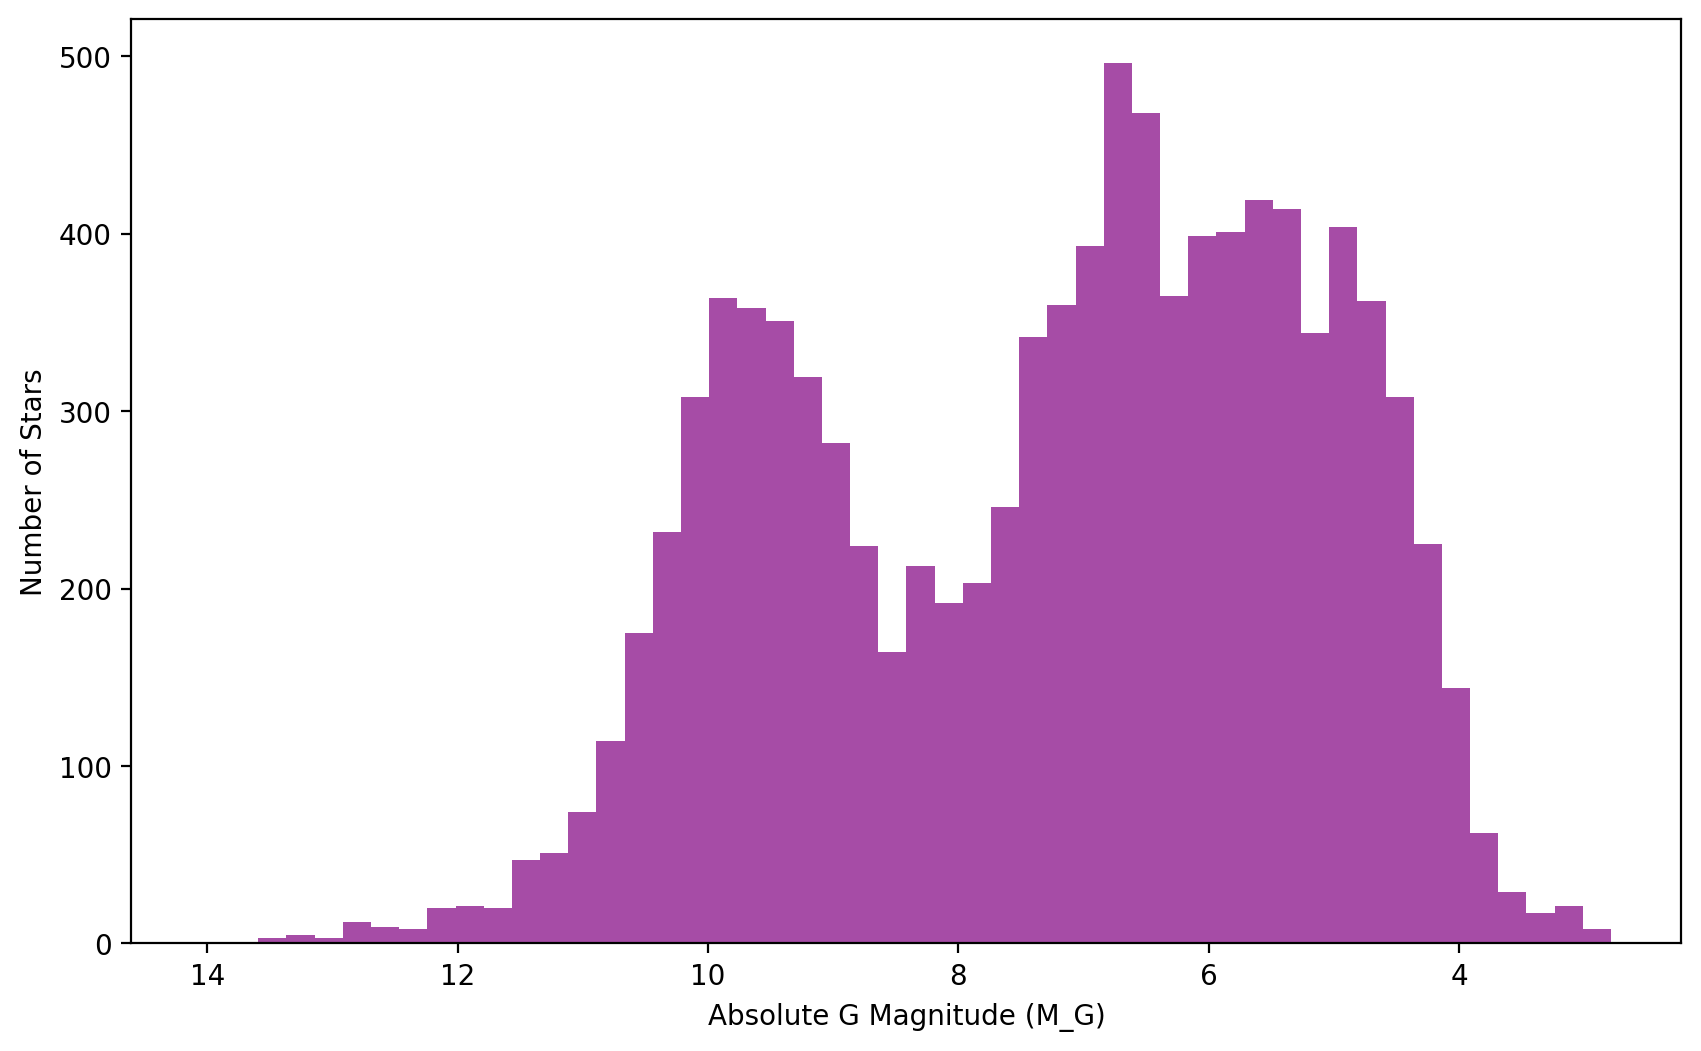

In [5]:
# Number distribution function of MG
data_path = "/home/wyt/Dyn/Dynamical-masses/data/jd_single_1kpc_filtered.fits"
data = Table.read(data_path)

# randomly choose 5000 systems for faster testing
rng = np.random.default_rng(42)
indices = rng.choice(len(data), size=5000, replace=False)
data = data[indices]


fig, ax = plt.subplots(figsize=(10, 6))
plt.hist(np.concatenate([data['absg1'], data['absg2']]), bins=50, density=False, alpha=0.7, color='purple')
absg_all = np.concatenate([data['absg1'], data['absg2']])
absg_lo, absg_hi = np.nanpercentile(absg_all, [1, 99])
absg_min_val = globals().get('absg_min', None)
absg_max_val = globals().get('absg_max', None)
plot_absg_min = absg_lo if absg_min_val is None else absg_min_val
plot_absg_max = absg_hi if absg_max_val is None else absg_max_val
ax.axvline(plot_absg_min, color='black', linestyle='--', linewidth=1.5, label=f'absg_min={plot_absg_min:.2f}')
ax.axvline(plot_absg_max, color='black', linestyle='--', linewidth=1.5, label=f'absg_max={plot_absg_max:.2f}')
ax.legend()
plt.xlabel('Absolute G Magnitude (M_G)')
plt.ylabel('Number of Stars')
# invert x-axis
plt.gca().invert_xaxis()
plt.show()

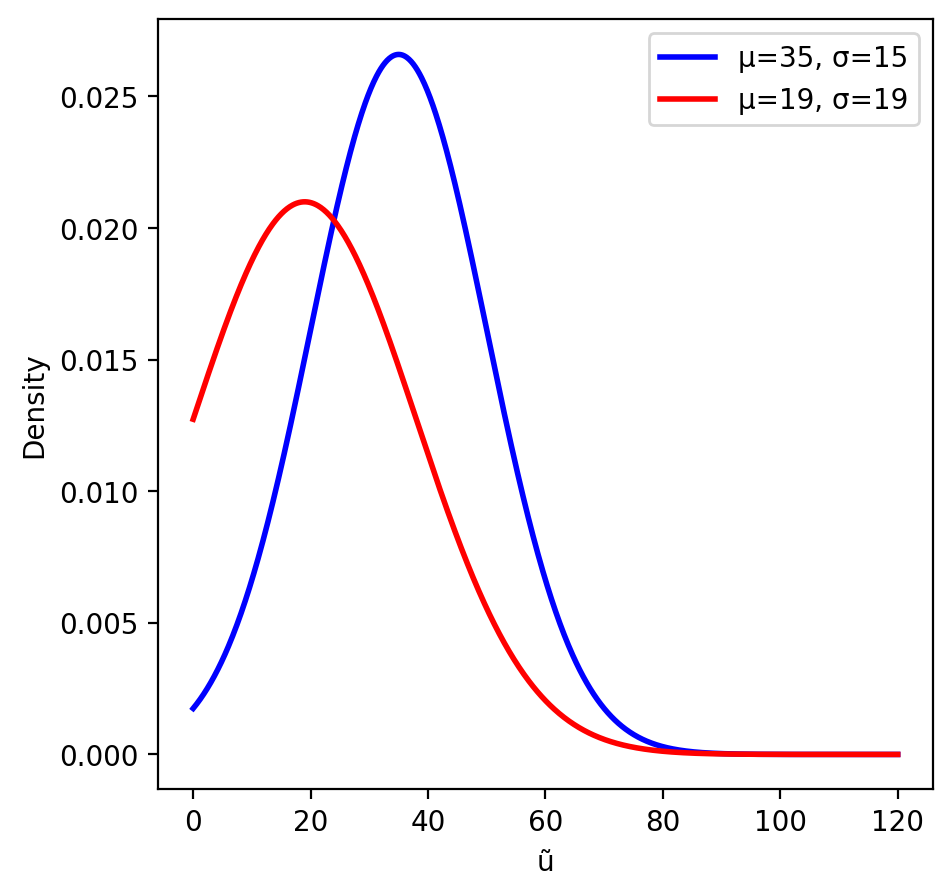

In [8]:
# compare Gaussian distribution profile: mu=35, sigma=15 and mu=19, sigma=19
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
def gaussian_pdf(x, mu, sigma):
    return norm.pdf(x, loc=mu, scale=sigma)

def main():
    # Parameters for the original distribution
    mu, sigma = 35, 15  # mean and standard deviation
    mu1, sigma1 = 19, 19

    # Create a range of x values
    u_range = np.linspace(0, 120, 1000)
    pdf_values = gaussian_pdf(u_range, mu, sigma)
    pdf_values1 = gaussian_pdf(u_range, mu1, sigma1)

    # Plotting
    fig, axes = plt.subplots(1, 1, figsize=(5, 5))

    # Original PDF
    axes.plot(u_range, pdf_values, 'b-', linewidth=2, label='μ=35, σ=15')
    axes.plot(u_range, pdf_values1, 'r-', linewidth=2, label='μ=19, σ=19')
    axes.set_xlabel('ũ')
    axes.set_ylabel('Density')

    plt.legend()
    plt.show()


main()

# Predict masses with the trained model

In [14]:
from binary_masses.differencepoly_feh import DifferencePolyFehMLR, IsochroneMassSurfaceModel

# after fitting
# fitter = DifferencePolyFehMLR()

# option A: use in-memory posterior samples
# pred = fitter.predict_masses(absg, feh)
# m16, m50, m84 = pred["p16"], pred["p50"], pred["p84"]

# import data
data_path = "/home/wyt/Dyn/Dynamical-masses/data/mock_data_efuncu_galaxiad_imfm_unifmh_obserr_outlier_diff2d_mg35_135_withpred.fits"
data = Table.read(data_path)

# option B: load samples from txt
iso_surface = IsochroneMassSurfaceModel.from_interpolated_mass_data(
        "/home/wyt/Dyn/Dynamical-masses/data/interpolated_mass_data",
        mass_min=0.05,
    )
fitter = DifferencePolyFehMLR(
        order=2,
        isochrone_surface_model=iso_surface,
        feh_min=-1,
        feh_max=0.6,
        mass_min=0.05,
        mass_max=2,
        absg_min=3.5,
        absg_max=13.5,
        uncertainty_model="gaussian",
        f_outlier=0.1,
        outlier_u0=35,
        outlier_sigma=15,
        outlier_kappa_scale=1,
        fit_outlier_params=True,
        param_truths=None,
        coeff_prior_scale=3.0,
        feh_coeff_prior_scale=3.0,
        deriv_penalty_strength=0,
        feh_monotone_strength=0,
        monotone_n_feh=5,
        feh_model="quadratic2d",
        cross_mode="free",
    )

fitter.load_samples_txt("/home/wyt/Dyn/Dynamical-masses/results/test_diffpoly2d_feh_mock2/mcmc_model-differencepolyfeh_unc-gaussian_fehcont_outlierfit_order2_feh[-1.00,+0.60].txt")
pred1 = fitter.predict_masses(data['absg1'], data['feh'])
pred2 = fitter.predict_masses(data['absg2'], data['feh'])

# option C: pass samples directly (array)
# pred = fitter.predict_masses(absg, feh, params_samples=your_samples_array)

# optional: speed up by sub-sampling
# pred = fitter.predict_masses(data['absg'], data['feh'], sample_limit=500, rng=42)

In [6]:
pred1

{'p16': array([0.50749325, 0.31467993, 0.49459484, ..., 0.43926928, 0.47523081,
        0.37189994]),
 'p50': array([0.5204493 , 0.32378292, 0.51518148, ..., 0.44970676, 0.48914496,
        0.38161577]),
 'p84': array([0.53428274, 0.33334182, 0.53742383, ..., 0.46092057, 0.50324094,
        0.3921043 ])}

In [15]:
data["m_pred_o1"] = pred1["p50"]
data["m_pred_o2"] = pred2["p50"]
data["m_pred_o1_p16"] = pred1["p16"]
data["m_pred_o1_p84"] = pred1["p84"]
data["m_pred_o2_p16"] = pred2["p16"]
data["m_pred_o2_p84"] = pred2["p84"]

# save to new fits file
data.write("/home/wyt/Dyn/Dynamical-masses/data/mock_data_efuncu_galaxiad_imfm_unifmh_obserr_outlier_diff2d_mg35_135_withpred.fits", overwrite=True)